# SC2001 Project 1: Integration of Merge Sort & Insertion Sort
Every sort function returns the number of **key comparisons** it made (one comparison between two array elements).

In [1]:
import math
import random
import time

import matplotlib.pyplot as plt

## (a) Algorithm implementation

### Insertion sort on arr[left..right]

In [4]:
def insertion_sort(arr, left, right):
    comparisons = 0
    for i in range(left + 1, right + 1):
        key = arr[i]
        j = i - 1
        while j >= left:
            comparisons += 1
            if arr[j] > key:
                arr[j + 1] = arr[j]   # shift bigger element right
                j -= 1
            else:
                break
        arr[j + 1] = key
    return comparisons

### Merge sorted halves arr[left..mid] and arr[mid+1..right]

In [5]:
def merge(arr, left, mid, right):
    left_half = arr[left:mid + 1]
    right_half = arr[mid + 1:right + 1]
    i = 0
    j = 0
    k = left
    comparisons = 0

    while i < len(left_half) and j < len(right_half):
        comparisons += 1
        if left_half[i] <= right_half[j]:
            arr[k] = left_half[i]
            i += 1
        else:
            arr[k] = right_half[j]
            j += 1
        k += 1

    # one half is used up: copy the rest of the other half (no comparisons)
    arr[k:right + 1] = left_half[i:] + right_half[j:]
    return comparisons

### Hybrid sort: insertion sort once the subarray size is ≤ S

In [6]:
def hybrid_sort(arr, left, right, S):
    if right - left + 1 <= S:
        return insertion_sort(arr, left, right)
    mid = (left + right) // 2
    comparisons = hybrid_sort(arr, left, mid, S)
    comparisons += hybrid_sort(arr, mid + 1, right, S)
    comparisons += merge(arr, left, mid, right)
    return comparisons

## (b) Generate input data
n random integers in [1, x]. We use **x = n**, so the share of duplicate values is the same for every size. A fixed seed gives the same array every run.

In [7]:
def generate_data(n, x, seed):
    rng = random.Random(seed)
    return rng.choices(range(1, x + 1), k=n)


SIZES = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000,
         500000, 1000000, 2000000, 5000000, 10000000]

## (d) Original merge sort
Defined here so the correctness checks below can test both sorts.

In [8]:
def merge_sort(arr, left, right):
    if left >= right:
        return 0
    mid = (left + right) // 2
    comparisons = merge_sort(arr, left, mid)
    comparisons += merge_sort(arr, mid + 1, right)
    comparisons += merge(arr, left, mid, right)
    return comparisons

### Correctness checks

In [9]:
# 1. both sorts give the right result, including edge cases
cases = [[], [5], [2, 1], [7] * 50, list(range(100)), list(range(100, 0, -1)),
         generate_data(5000, 5000, seed=1)]
for data in cases:
    arr = data.copy()
    merge_sort(arr, 0, len(arr) - 1)
    assert arr == sorted(data), "merge sort gave wrong result"
    for S in [1, 5, 20, 100, 10000]:
        arr = data.copy()
        hybrid_sort(arr, 0, len(arr) - 1, S)
        assert arr == sorted(data), "hybrid sort gave wrong result"
print("Merge sort and hybrid sort give correct results.")

# 2. comparison counts are right
# S = 1: insertion sort never compares, so hybrid must count the same as merge sort
data = generate_data(10000, 10000, seed=2)
assert hybrid_sort(data.copy(), 0, 9999, 1) == merge_sort(data.copy(), 0, 9999)
# reverse sorted input is insertion sort's worst case: n(n-1)/2 comparisons
assert insertion_sort(list(range(200, 0, -1)), 0, 199) == 200 * 199 // 2
print("Comparison counts are correct.")

Merge sort and hybrid sort give correct results.
Comparison counts are correct.


## (c) Analyze time complexity
### Helpers
`run` sorts fresh copies of the data and returns the key comparisons and average CPU time.

`theoretical_comparisons` gives C(n, S) ≈ n·k + n·m/4, where k is the number of halvings until pieces have size m ≤ S.

In [10]:
def run(data, S=None, repeats=1):
    # S = None runs the original merge sort, otherwise the hybrid sort.
    copies = [data.copy() for _ in range(repeats)]   # copy before the timer starts
    start = time.process_time()
    for arr in copies:
        if S is None:
            comparisons = merge_sort(arr, 0, len(arr) - 1)
        else:
            comparisons = hybrid_sort(arr, 0, len(arr) - 1, S)
    cpu_time = (time.process_time() - start) / repeats
    return comparisons, cpu_time


def theoretical_comparisons(n, S):
    # Each halving adds one merge level costing about n comparisons.
    # The n/size pieces are insertion sorted at about size^2/4 each.
    levels = 0
    size = n
    while size > S:
        size = size / 2
        levels += 1
    return n * levels + n * size / 4

### (c)(i) Key comparisons vs n (S fixed)
*Takes a few minutes (includes 10 million).*

n = 1000: comparisons = 9129, theory = 8953, empirical / theory = 1.020
n = 2000: comparisons = 20305, theory = 19906, empirical / theory = 1.020
n = 5000: comparisons = 58399, theory = 57207, empirical / theory = 1.021
n = 10000: comparisons = 126604, theory = 124414, empirical / theory = 1.018
n = 20000: comparisons = 274883, theory = 268828, empirical / theory = 1.023
n = 50000: comparisons = 728785, theory = 726294, empirical / theory = 1.003
n = 100000: comparisons = 1557539, theory = 1552588, empirical / theory = 1.003
n = 200000: comparisons = 3315627, theory = 3305176, empirical / theory = 1.003
n = 500000: comparisons = 9036401, theory = 8953674, empirical / theory = 1.009
n = 1000000: comparisons = 19074743, theory = 18907349, empirical / theory = 1.009
n = 2000000: comparisons = 40144168, theory = 39814697, empirical / theory = 1.008
n = 5000000: comparisons = 108210746, theory = 106920929, empirical / theory = 1.012
n = 10000000: comparisons = 226420481, theory = 223841858,

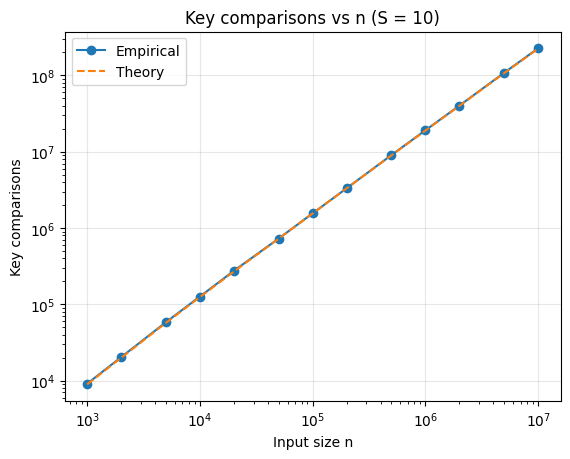

In [11]:
S = 10
comparisons_list = []
theory_list = []

for n in SIZES:
    comparisons = run(generate_data(n, n, seed=n), S)[0]
    theory = theoretical_comparisons(n, S)
    comparisons_list.append(comparisons)
    theory_list.append(theory)
    print(f"n = {n}: comparisons = {comparisons}, theory = {theory:.0f}, "
          f"empirical / theory = {comparisons / theory:.3f}")

plt.plot(SIZES, comparisons_list, "o-", label="Empirical")
plt.plot(SIZES, theory_list, "--", label="Theory")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Input size n")
plt.ylabel("Key comparisons")
plt.title(f"Key comparisons vs n (S = {S})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### (c)(ii) Key comparisons vs S (n fixed)

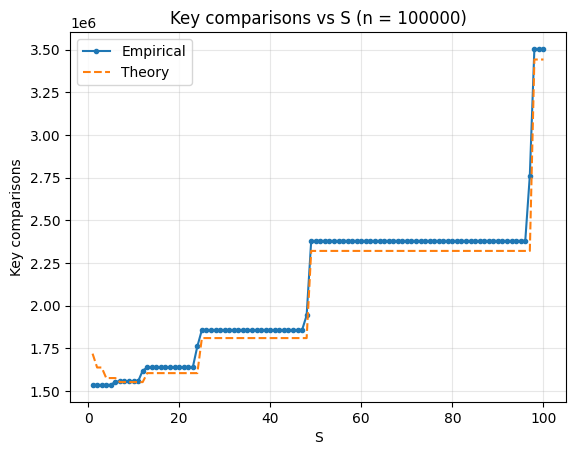

In [12]:
n = 100000
data = generate_data(n, n, seed=n)   # same array for every S
S_values = list(range(1, 101))
comparisons_list = []
theory_list = []

for S in S_values:
    comparisons = run(data, S)[0]
    comparisons_list.append(comparisons)
    theory_list.append(theoretical_comparisons(n, S))

plt.plot(S_values, comparisons_list, "o-", markersize=3, label="Empirical")
plt.plot(S_values, theory_list, "--", label="Theory")
plt.xlabel("S")
plt.ylabel("Key comparisons")
plt.title(f"Key comparisons vs S (n = {n})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### (c)(iii) Optimal S for different n
*Takes around 15 minutes.*

n = 1000: best S by comparisons = 3, best S by CPU time = 20
n = 10000: best S by comparisons = 3, best S by CPU time = 10
n = 100000: best S by comparisons = 3, best S by CPU time = 36
n = 1000000: best S by comparisons = 1, best S by CPU time = 50


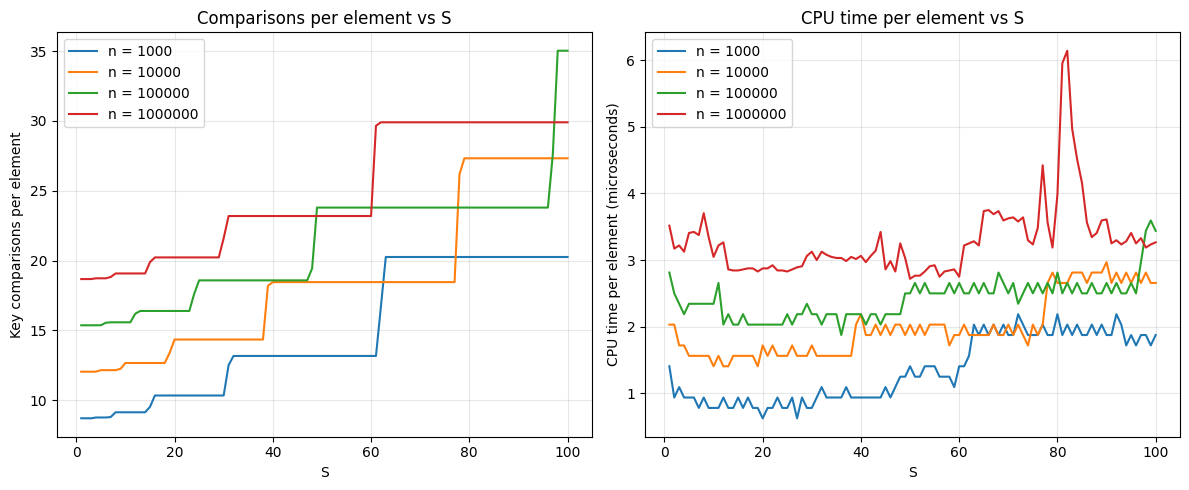

In [13]:
S_values = list(range(1, 101))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for n in [1000, 10000, 100000, 1000000]:
    data = generate_data(n, n, seed=n)
    # small sorts are too fast for the timer to measure well,
    # so they are repeated and the time is averaged
    repeats = max(1, 100000 // n)
    comparisons_list = []
    time_list = []

    for S in S_values:
        comparisons, cpu_time = run(data, S, repeats)
        comparisons_list.append(comparisons)
        time_list.append(cpu_time)

    best_S_comparisons = S_values[comparisons_list.index(min(comparisons_list))]
    best_S_time = S_values[time_list.index(min(time_list))]
    print(f"n = {n}: best S by comparisons = {best_S_comparisons}, "
          f"best S by CPU time = {best_S_time}")

    # divide by n so different sizes fit on the same chart
    ax1.plot(S_values, [c / n for c in comparisons_list], label=f"n = {n}")
    ax2.plot(S_values, [t / n * 1000000 for t in time_list], label=f"n = {n}")

ax1.set_xlabel("S")
ax1.set_ylabel("Key comparisons per element")
ax1.set_title("Comparisons per element vs S")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.set_xlabel("S")
ax2.set_ylabel("CPU time per element (microseconds)")
ax2.set_title("CPU time per element vs S")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## (d) Compare with original merge sort (n = 10 million)
Uses the optimal S from (c)(iii). *Takes a few minutes.*

In [1]:
S = 20
n = 10000000
data = generate_data(n, n, seed=n)   # both sorts get the same array

hybrid_comparisons, hybrid_time = run(data, S)
merge_comparisons, merge_time = run(data)

print(f"{'':20}{'Comparisons':>15}{'CPU time (s)':>15}")
print(f"{f'Hybrid (S = {S})':20}{hybrid_comparisons:>15}{hybrid_time:>15.2f}")
print(f"{'Merge sort':20}{merge_comparisons:>15}{merge_time:>15.2f}")
print(f"Hybrid / merge sort: comparisons = {hybrid_comparisons / merge_comparisons:.3f}, "
      f"CPU time = {hybrid_time / merge_time:.3f}")

NameError: name 'generate_data' is not defined